# 03A - Exploratory Data Analysis: Univariate Analysis

**Objective:** Explore the distribution and statistical properties of each numeric feature before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(8,4)
df=pd.read_csv("../data/datasets/american_bankruptcy.csv")
num=df.select_dtypes(include='number')


## Dataset Overview

In [2]:
display(num.head())
print(f"Numeric Features: {len(num.columns)}")

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


Numeric Features: 19


## Summary Statistics

In [3]:
summary=num.describe().T
summary['median']=num.median()
summary['skewness']=num.skew()
summary['kurtosis']=num.kurtosis()
display(summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
year,78682.0,2007.506317,5.742768,1999.0000,2002.00000,2007.00000,2012.00000,2018.00,2007.00000,0.193910,-1.173620
X1,78682.0,880.362485,3928.564794,-7.7600,18.92400,100.44950,431.52675,169662.00,100.44950,14.843279,337.487671
X2,78682.0,1594.529029,8930.484664,-366.6450,17.03825,103.66100,634.54800,374623.00,103.66100,20.052194,577.346146
X3,78682.0,121.234256,652.376804,0.0000,1.19200,7.92950,47.97175,28430.00,7.92950,17.860473,445.439352
X4,78682.0,376.759424,2012.023142,-21913.0000,-0.81100,15.03450,139.65525,81730.00,15.03450,16.403531,399.842632
X5,78682.0,201.605717,1060.766096,0.0000,0.00000,7.02300,74.74725,62567.00,7.02300,22.568626,814.509528
X6,78682.0,129.382453,1265.532022,-98696.0000,-7.41575,1.61600,40.14425,104821.00,1.61600,11.866809,1496.321577
X7,78682.0,286.832743,1335.978571,-0.0060,3.28125,22.82000,131.58050,65812.00,22.82000,15.844958,400.358914
X8,78682.0,3414.354610,18414.103647,0.0001,34.98000,227.51185,1244.88995,1073390.54,227.51185,18.194283,541.009800
X9,78682.0,2364.019706,11950.068842,-1964.9990,27.54850,186.59850,1046.40250,511729.00,186.59850,18.987110,546.058983


## Missing Values

In [4]:
display(num.isna().sum().to_frame('Missing'))

,Missing
year,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0


## Histograms

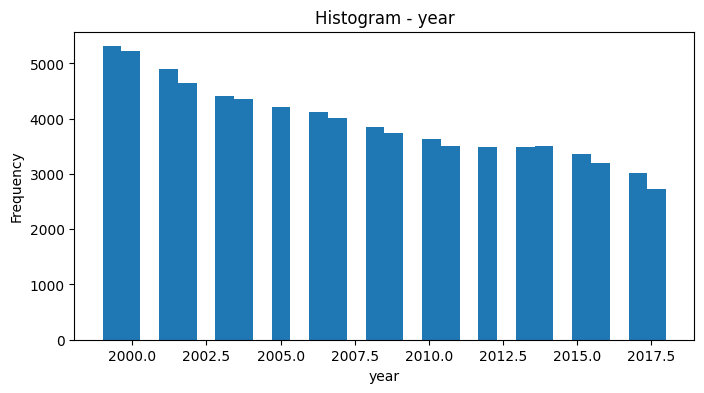

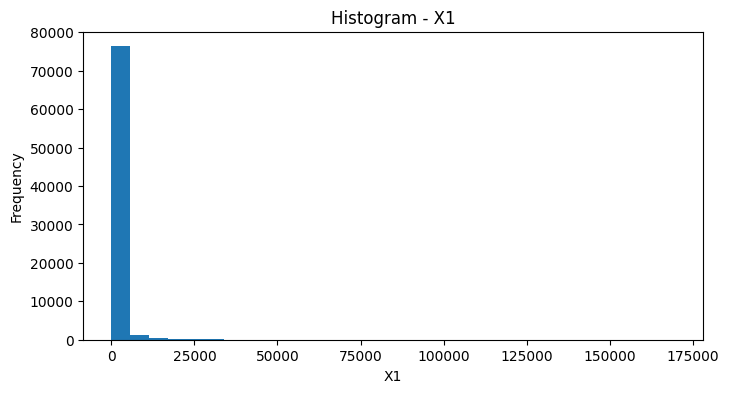

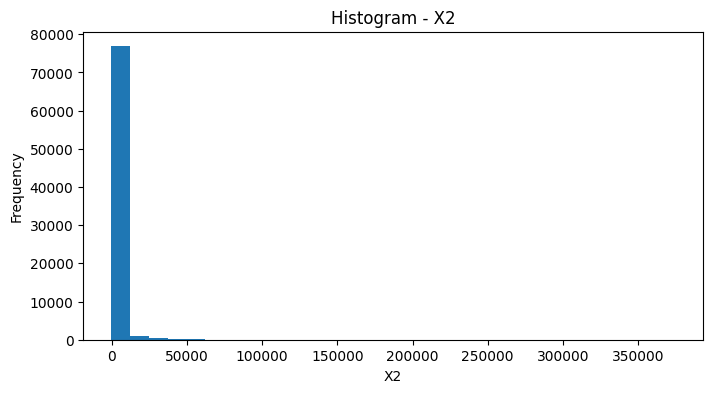

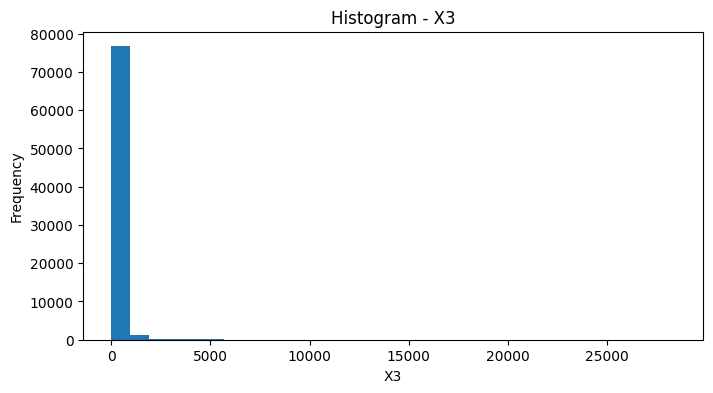

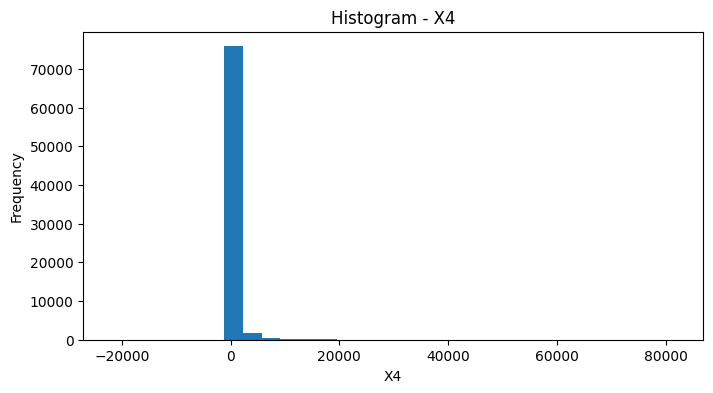

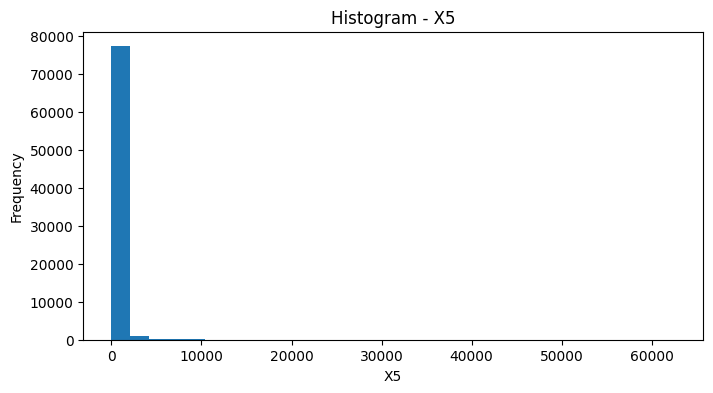

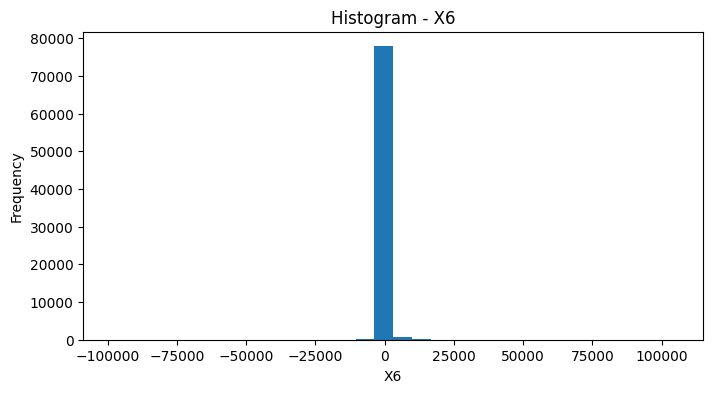

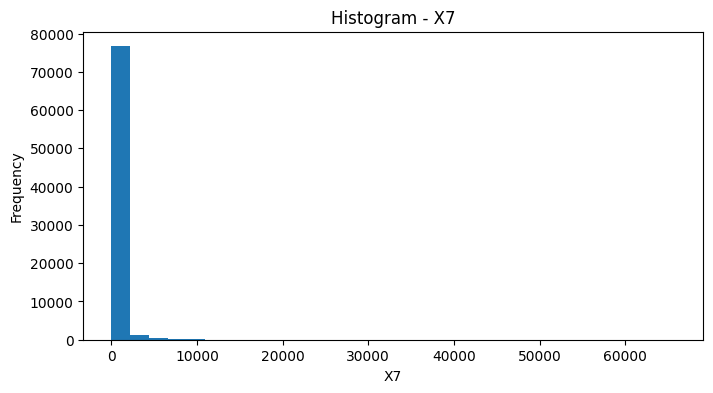

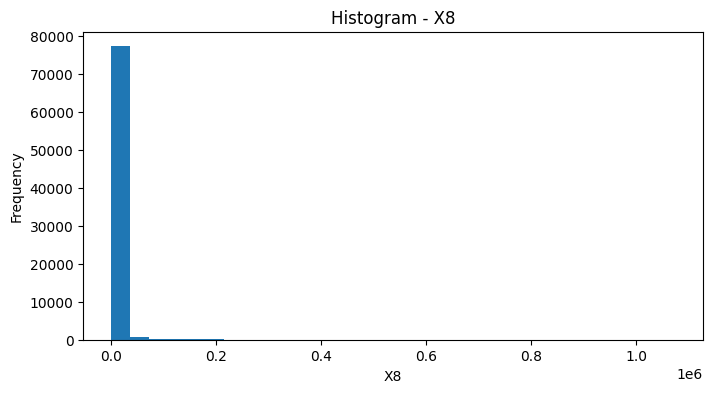

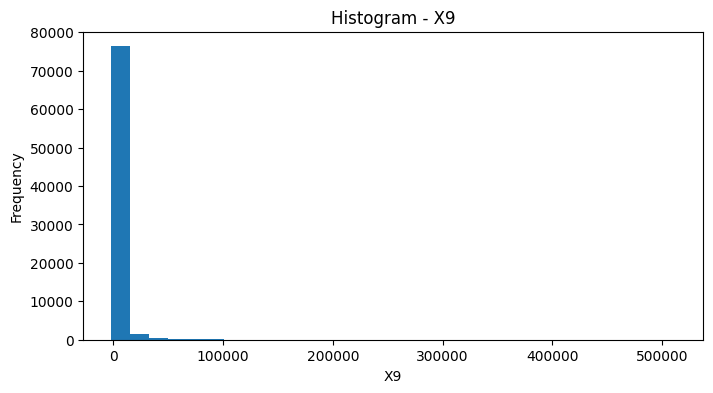

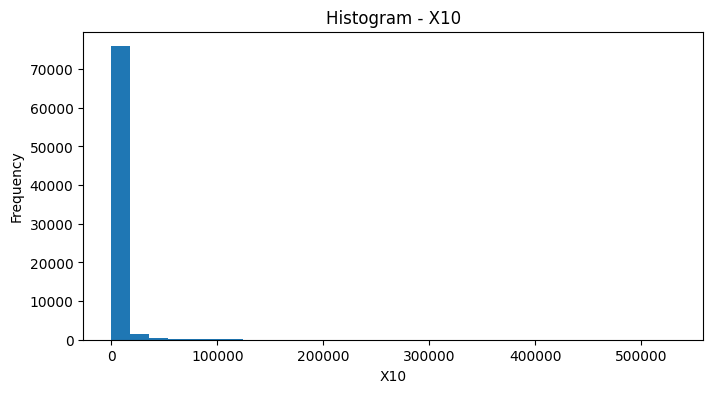

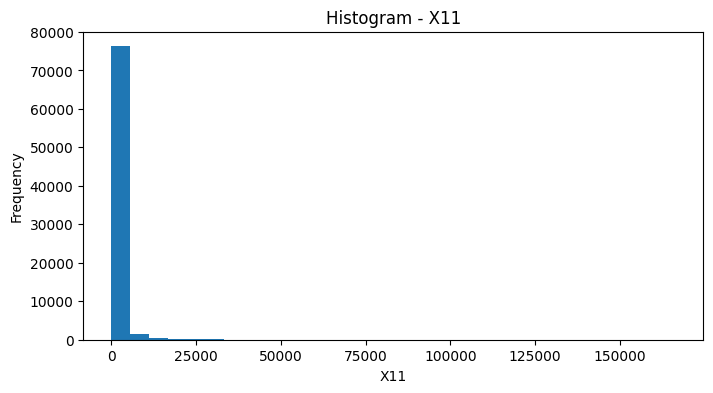

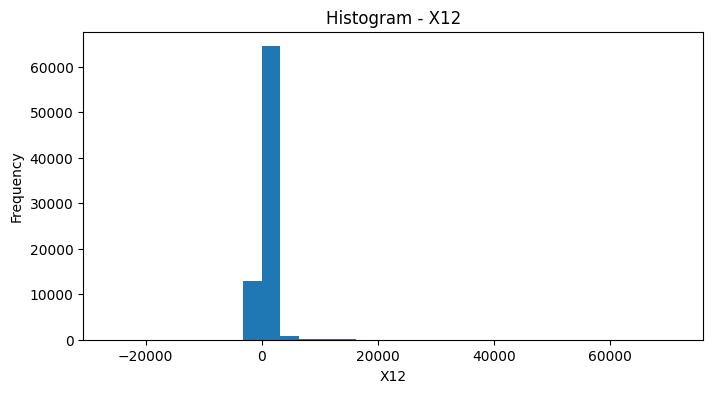

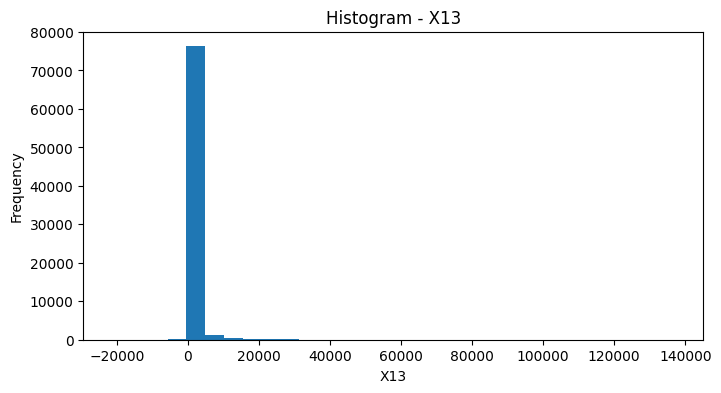

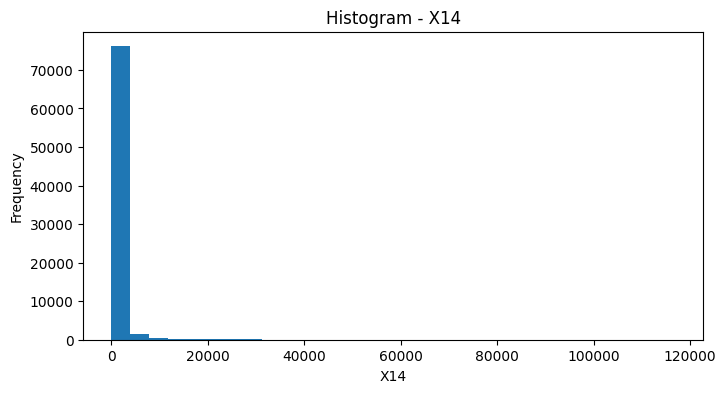

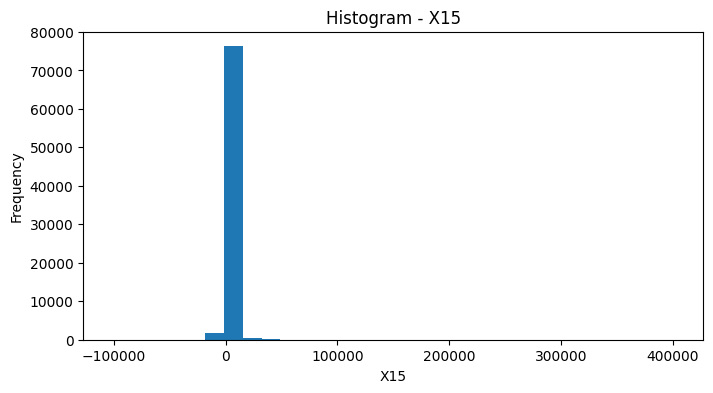

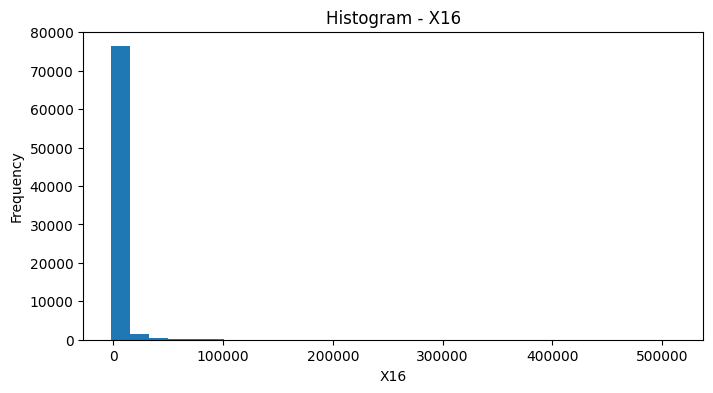

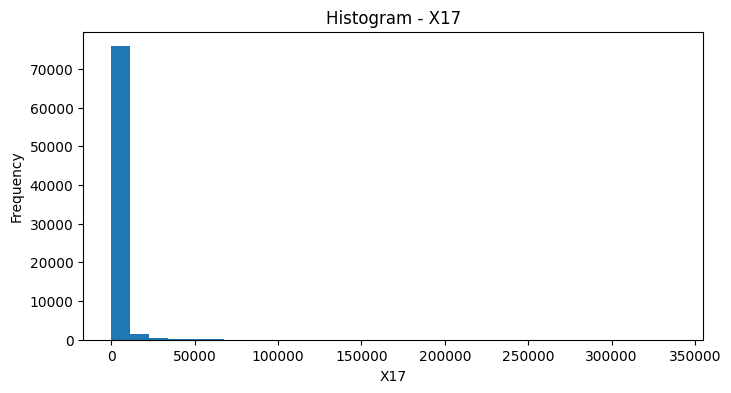

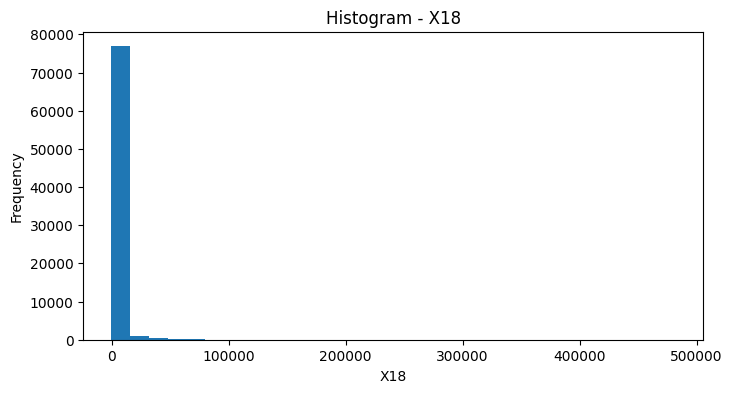

In [5]:
for col in num.columns:
    plt.figure()
    plt.hist(num[col].dropna(),bins=30)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Boxplots

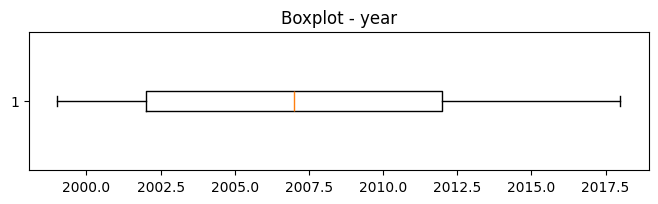

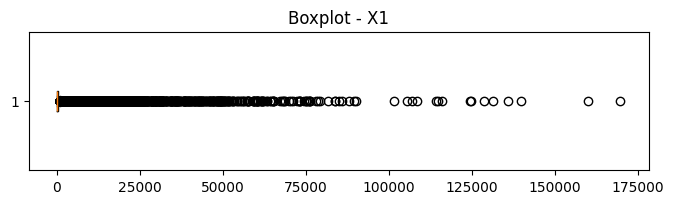

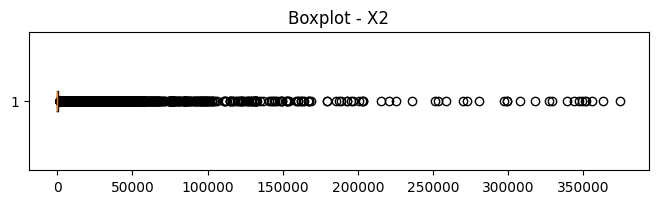

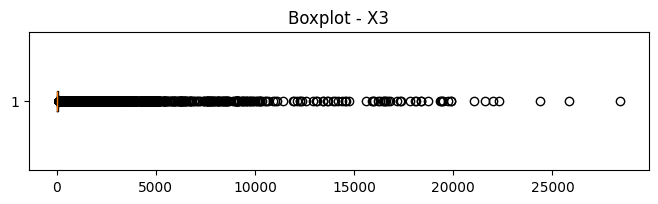

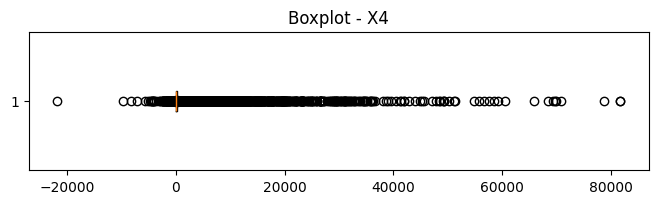

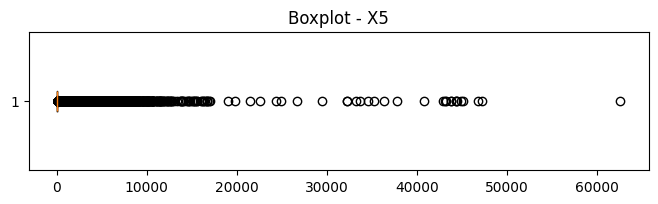

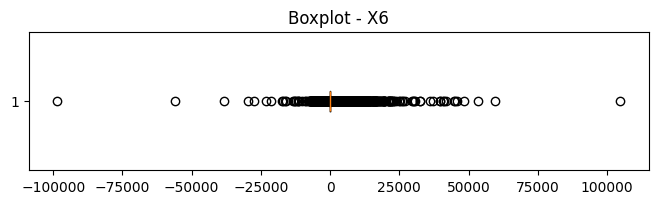

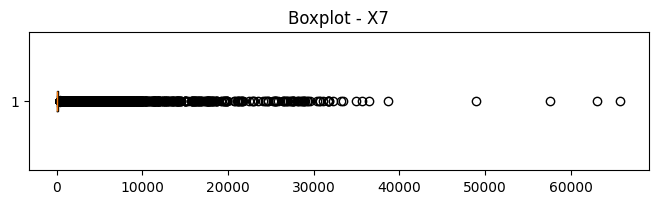

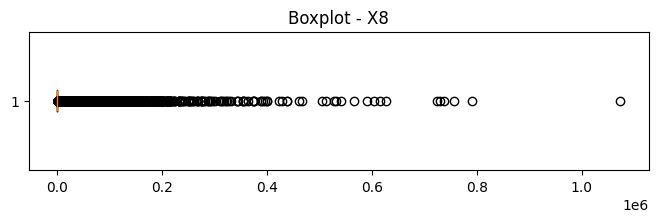

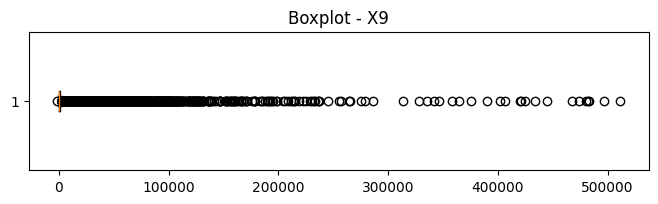

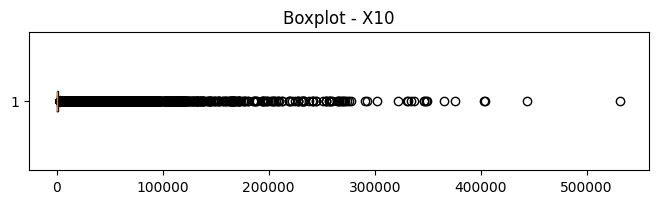

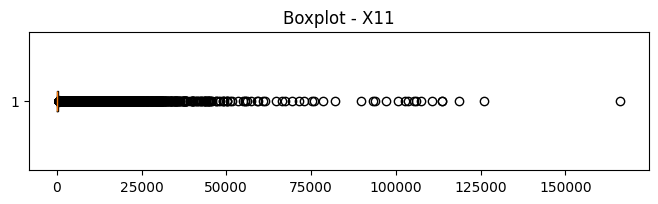

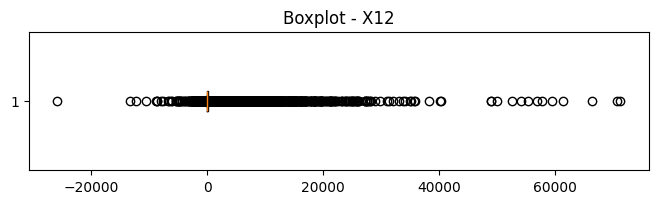

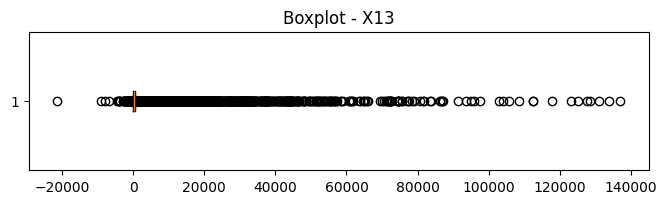

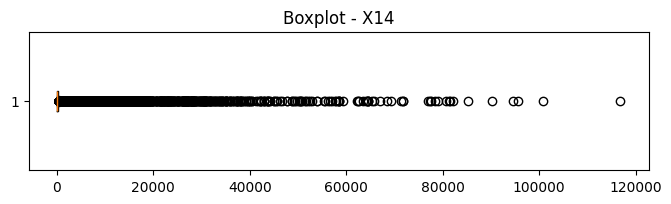

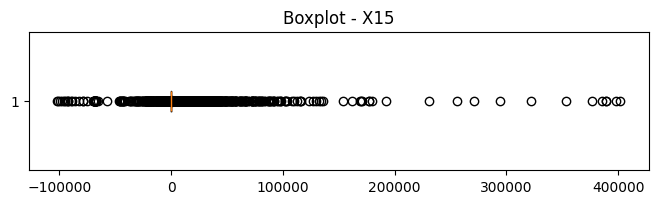

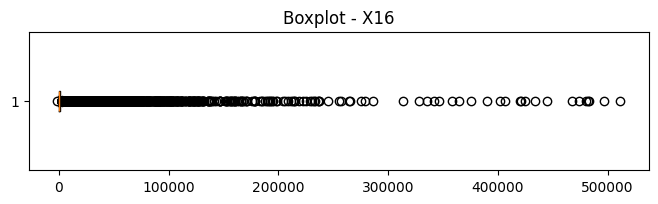

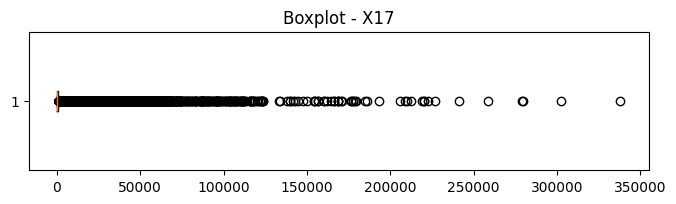

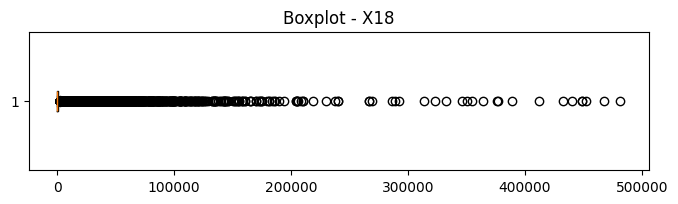

In [6]:
for col in num.columns:
    plt.figure(figsize=(8,1.8))
    plt.boxplot(num[col].dropna(),vert=False)
    plt.title(f'Boxplot - {col}')
    plt.show()

## Distribution Shape

In [7]:
dist=pd.DataFrame({
    'Skewness':num.skew(),
    'Kurtosis':num.kurtosis()
})
display(dist.sort_index())

,Skewness,Kurtosis
X1,14.843279,337.487671
X10,13.562208,272.664160
X11,14.848021,387.451636
X12,17.968030,528.509445
X13,15.295829,335.142459
X14,14.225186,293.602173
X15,29.607949,1544.146161
X16,18.987110,546.058983
X17,13.767802,296.442354
X18,20.384520,631.459066


## Basic Interpretation

In [8]:
for c in num.columns:
    s=num[c].skew()
    if abs(s)<0.5:
        label='Approximately symmetric'
    elif s>0:
        label='Right-skewed'
    else:
        label='Left-skewed'
    print(f'{c}: {label} (skew={s:.2f})')

year: Approximately symmetric (skew=0.19)
X1: Right-skewed (skew=14.84)
X2: Right-skewed (skew=20.05)
X3: Right-skewed (skew=17.86)
X4: Right-skewed (skew=16.40)
X5: Right-skewed (skew=22.57)
X6: Right-skewed (skew=11.87)
X7: Right-skewed (skew=15.84)
X8: Right-skewed (skew=18.19)
X9: Right-skewed (skew=18.99)
X10: Right-skewed (skew=13.56)
X11: Right-skewed (skew=14.85)
X12: Right-skewed (skew=17.97)
X13: Right-skewed (skew=15.30)
X14: Right-skewed (skew=14.23)
X15: Right-skewed (skew=29.61)
X16: Right-skewed (skew=18.99)
X17: Right-skewed (skew=13.77)
X18: Right-skewed (skew=20.38)


## Key Findings

In [9]:
findings=[
'Review highly skewed variables before modeling.',
'Investigate variables with extreme outliers.',
'Scaling or transformation may be required for some features.',
'Summary statistics provide a baseline for later feature engineering.'
]
for i,f in enumerate(findings,1):
    print(f'{i}. {f}')

1. Review highly skewed variables before modeling.
2. Investigate variables with extreme outliers.
3. Scaling or transformation may be required for some features.
4. Summary statistics provide a baseline for later feature engineering.
